In [1]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import netCDF4
import glob
from natsort import natsorted
from matplotlib.colors import Normalize
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
from joblib import Parallel, delayed

## Post-simulation reality check

[]


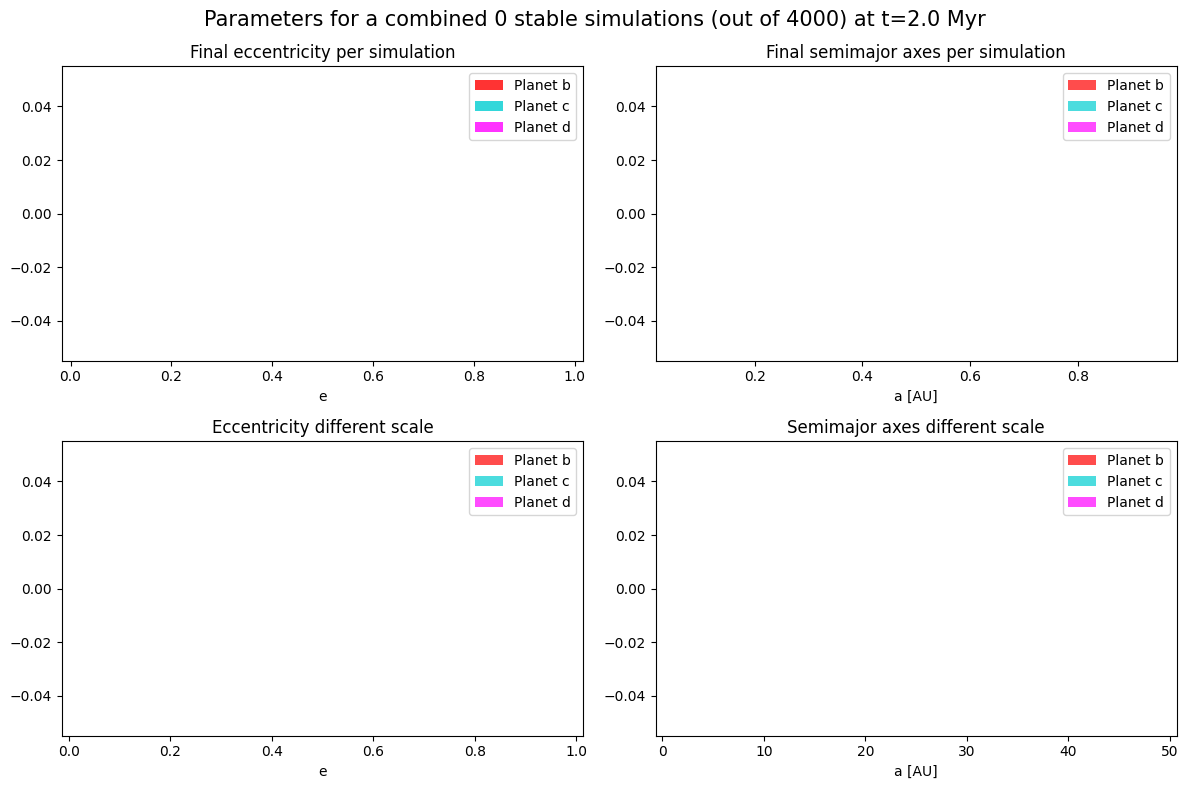

In [2]:
# run_numbers = np.linspace(0, 72, 73)
# mass_files = []
# for run in run_numbers:
#     files = glob.glob(f'mass_sampling_results/run_{int(run)}_*core_2_3p.nc')
#     mass_files.extend(files)

mass_files = glob.glob(f'mass_sampling_results/run*_3p_MMR.nc')

def reality_check(filenames):

    N = len(filenames)

    all_a = np.zeros((3, N))
    all_e = np.zeros((3, N))
    distance = np.zeros((3, N))
    cross_disk = []
    for i, file in enumerate(filenames):
        with netCDF4.Dataset(file, 'r') as ncfile:   
            
            tmax = ncfile['times'][-1]

            massive_bodies_e = ncfile['planets'][:, 0, :, 0]
            massive_bodies_a = ncfile['planets'][:, 0, :, 1]

        distance = massive_bodies_a * (1 + massive_bodies_e)
        distance_small = massive_bodies_a * (1 - massive_bodies_e)
        c3 = (np.all(distance[:,2] < distance_small[:,0])) and (np.all(distance[:,0] < distance_small[:,1]) ) 

            
        if (np.all(distance[1]) >= 40) and (np.all(distance[1] <= 87)) and c3 and "core_4_" in file:
            cross_disk.append(file)

        #for obj in range(3):

            # if np.all((distance) < 87) and np.all(massive_bodies_a > 0) and c3:
            #     all_a[obj][i] = massive_bodies_a[obj]
            #     all_e[obj][i] = massive_bodies_e[obj]

    print(cross_disk)

    valid_as = np.array([all_a[i][all_a[i] !=0] for i in range(3)])
    valid_es = np.array([all_e[i][all_e[i] != 0] for i in range(3)])
    colors = ['red', 'darkturquoise', 'magenta']
    labels = ['Planet b', 'Planet c', 'Planet d']

    n_col = 2
    fig, ax = plt.subplots(2, n_col, figsize=(12,8))
    ax[0, 1].hist(valid_as.T, bins=5, color=colors, label=labels, alpha=0.7, rwidth = 0.4)
    ax[1, 1].hist(valid_as.T, bins=np.linspace(0, 50, 10), color=colors, label=labels, alpha=0.7, rwidth = 0.4)
    ax[0, 1].set_title('Final semimajor axes per simulation')
    ax[1, 1].set_xlabel('a [AU]')
    ax[0, 1].set_xlabel('a [AU]')
    ax[1, 1].set_title('Semimajor axes different scale')
    ax[0, 0].hist(valid_es.T, bins=10, color=colors, label=labels, alpha=0.8, rwidth = 0.4)
    ax[1, 0].hist(valid_es.T, bins=np.linspace(0, 1, 10), color=colors, label=labels, alpha=0.7, rwidth = 0.4)
    ax[0, 0].set_title('Final eccentricity per simulation')
    ax[1, 0].set_title('Eccentricity different scale')
    ax[0, 0].set_xlabel('e')
    ax[1, 0].set_xlabel('e')

    for i in range(n_col):
        for j in range(n_col):
            ax[i,j].legend() 

    plt.suptitle(f'Parameters for a combined {len(valid_as[0])} stable simulations (out of {N}) at t={tmax/1e6:.2} Myr', fontsize=15)

    plt.tight_layout()

    return valid_as, valid_es

valid_as, valid_es = reality_check(mass_files)

In [3]:
valid_es.shape

(3, 0)

# Plotting 3 planets

#### First, group the files into even cores (where m_d = 0.1) and odd cores (where m_d = 2.3)

In [4]:
N_runs = 100  # Total number of runs
N_cores = 40  # Total cores per run

even_core_files = [[] for _ in range(N_cores // 2)]  # For m3=0.1 (even indices)
odd_core_files = [[] for _ in range(N_cores // 2)]   # For m3=2.3 (odd indices)

for run in range(N_runs):
    # Match files like 'run_0_*_core_*_3p.nc'
    run_files = natsorted(glob.glob(f'mass_sampling_results/run_{run}_*_core_*_3p_MMR.nc'))
    
    for file in run_files:
        # Extract core index from filename (e.g., 'run_0_2000000.0_yr_core_0_3p.nc' → 0)
        core_index = int(file.split('_')[-3])
        if core_index % 2 == 0:  # Even core (m3=0.1)
            even_core_files[core_index // 2].append(file)
        else:  # Odd core (m3=2.3)
            odd_core_files[core_index // 2].append(file)

print(odd_core_files)

[['mass_sampling_results/run_0_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_1_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_2_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_3_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_4_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_5_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_6_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_7_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_8_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_9_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_10_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_11_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_12_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_13_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_14_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_results/run_15_2000000.0_yr_core_1_3p_MMR.nc', 'mass_sampling_r

#### Or, if using 4 vals for mass_d:

In [4]:
from collections import defaultdict

# Initialize 4 result lists with 20 inner lists each (one per core group)
files1 = [[] for _ in range(20)]  # For cores 0,4,8,...
files2 = [[] for _ in range(20)]  # For cores 1,5,9,... 
files3 = [[] for _ in range(20)]  # For cores 2,6,10,...
files4 = [[] for _ in range(20)]  # For cores 3,7,11,...

filepaths =  natsorted(glob.glob(f'mass_sampling_results/run*core_*_3p_v2.nc'))
for filepath in filepaths:
    parts = filepath.split('_')
    run_num = int(parts[-7])  # run number
    core_index = int(parts[-3])  # core index
    
    # Determine which of the 20 core-groups this belongs to (0-19)
    core_group = core_index // 4
    
    # Group 0 (cores 0,4,8,...)
    if core_index % 4 == 0:
        files1[core_group].append(filepath)
    # Group 1 (cores 1,5,9,...)
    elif core_index % 4 == 1:
        files2[core_group].append(filepath)
    # Group 2 (cores 2,6,10,...)
    elif core_index % 4 == 2:
        files3[core_group].append(filepath)
    # Group 3 (cores 3,7,11,...)
    else:
        files4[core_group].append(filepath)

#### Now, take an average of a and e over all runs:

In [7]:
def compute_averages(files):
    run_counts = []
    mean_std_a = []
    mean_std_e = []
    #loop through all cores
    for core_index, core_file in enumerate(files):
        massive_bodies_e_std = np.zeros((len(core_file), 3))
        massive_bodies_a_std = np.zeros((len(core_file), 3))
        run_count = 0

        #loop through all 100 runs
        for index, run in enumerate(core_file):
            with netCDF4.Dataset(run, 'r') as ncfile:
                #[time, [mass_combo], [pds70b, pds70c, pds70d], [e, a]]
                massive_bodies_e = ncfile['planets'][:, 0, :, 0]
                # massive_bodies_a_init = ncfile['planets'][0, 0, :, 1]
                massive_bodies_a = ncfile['planets'][:, 0, :, 1]
                distance = massive_bodies_a * (1 + massive_bodies_e)
                distance_small = massive_bodies_a * (1- massive_bodies_e)
                #can change stability criteria
                c1 = np.all(massive_bodies_e < 1)
                c2 = np.all(distance <= 87)
                c2_2 = np.all(distance <= 200)
                c3 = (np.all(distance[:,2] < distance_small[:,0])) and (np.all(distance[:,0] < distance_small[:,1]) ) 
                if c1 and c2 and c3:
                    run_count += 1
                    #massive_bodies_e_diff[index] = massive_bodies_e_fin - massive_bodies_e_init
                    #massive_bodies_a_diff[index] =  massive_bodies_a_fin - massive_bodies_a_init
                    massive_bodies_a_std[index]  = np.std(ncfile['planets'][:, 0, :, 1], axis=0)
                    massive_bodies_e_std[index]  = np.std(ncfile['planets'][:, 0, :, 0], axis=0)

                # if c1 and c2_2 and c3 and not c2:
                #     if "_core_4_" in run:
                #         print('specifically', run)
                    
        mean_std_a.append(np.mean(massive_bodies_a_std, axis=0))
        mean_std_e.append(np.mean(massive_bodies_e_std, axis=0))
        run_counts.append(run_count)

    
    return mean_std_e, mean_std_a, run_counts



# groups = [files1, files2, files3, files4]

# res1, res2, res3, res4 = Parallel(n_jobs=4)(
#     delayed(compute_averages)(file) for file in groups
# )

#res1 = compute_averages(files1)
results_even = compute_averages(even_core_files)
results_odd = compute_averages(odd_core_files)

In [31]:
print(res1)

([array([0.03407198, 0.03155712, 0.0644162 ]), array([0.02627799, 0.01427435, 0.03638803]), array([0.02992658, 0.01023806, 0.03268605]), array([0.02231005, 0.00507262, 0.0214426 ]), array([0.02752056, 0.03170444, 0.05497688]), array([0.02775369, 0.01823042, 0.04837771]), array([0.02795792, 0.01133317, 0.04046736]), array([0.02062818, 0.00624387, 0.02702372]), array([0.01804297, 0.02371363, 0.03609605]), array([0.0259963 , 0.01905075, 0.05535996]), array([0.02905226, 0.01358618, 0.04968681]), array([0.02162617, 0.00816238, 0.03474758]), array([0.01331955, 0.0202105 , 0.02860822]), array([0.0207497 , 0.01603321, 0.05010497]), array([0.02159319, 0.01139044, 0.04094134]), array([0.02068981, 0.0081849 , 0.04044067]), array([0.00598944, 0.00909194, 0.01307603]), array([0.01746409, 0.01466137, 0.04500957]), array([0.02558201, 0.01412536, 0.05678589]), array([0.01847997, 0.00878435, 0.03770232])], [array([0.08686857, 0.15928242, 0.03090401]), array([0.22609959, 0.1150195 , 0.09038694]), array(

In [5]:
# masses_b = np.linspace(0.5, 5.3, 4)
# masses_c = np.linspace(0.2, 8.2, 7)
masses_b = np.linspace(1, 3, 5)
masses_c = np.linspace(1, 7, 4)
mass1_grid, mass2_grid = np.meshgrid(masses_b, masses_c)
print(mass2_grid)

def dict_to_grid(results, n_b, n_c, ecc=True):
    results_b_grid = np.zeros((n_c, n_b))
    results_c_grid = np.zeros((n_c, n_b))
    results_d_grid = np.zeros((n_c, n_b))
    all_kept_sims_grid = np.zeros((n_c, n_b))
    
    idx = 0

    if ecc:
        x = 0
    else:
        x = 1

    for i in range(n_b):
        for j in range(n_c):
            results_b_grid[j, i] = results[x][idx][0]  # Planet b
            results_c_grid[j, i] = results[x][idx][1]  # Planet c
            results_d_grid[j, i] = results[x][idx][2]
            all_kept_sims_grid[j, i] = results[2][idx]
            idx += 1
    
    return results_b_grid, results_c_grid, results_d_grid, all_kept_sims_grid


[[1. 1. 1. 1. 1.]
 [3. 3. 3. 3. 3.]
 [5. 5. 5. 5. 5.]
 [7. 7. 7. 7. 7.]]


#### If using 2 values for M_d:

/tmp/ipykernel_3626088/2292486722.py:84: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()#(rect=[0, 0.05, 0.97, 0.97])  # Leave space at bottom/top


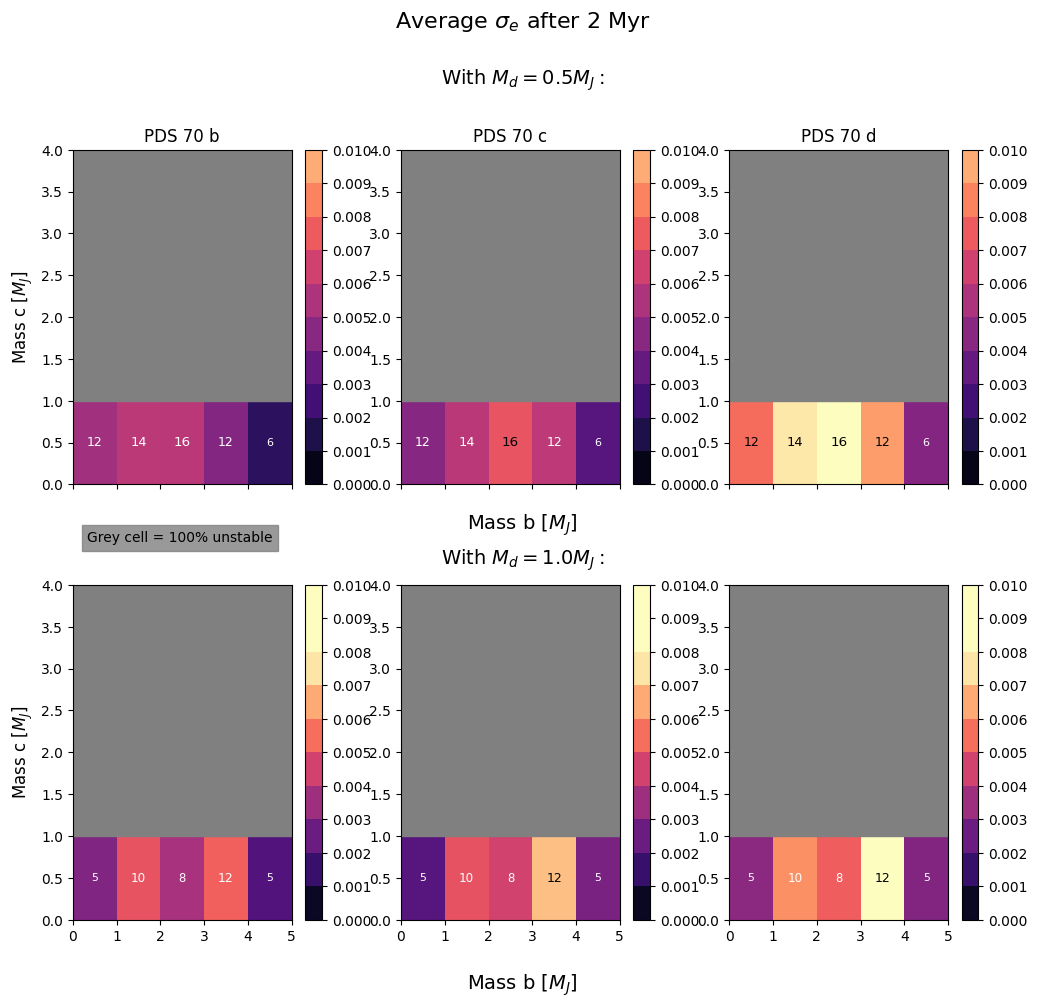

In [8]:
def plot_heatmap(ecc=True):
    plot_even_b, plot_even_c, plot_even_d, even_counts = dict_to_grid(results_even, n_b = 5, n_c = 4, ecc=True)
    plot_odd_b, plot_odd_c, plot_odd_d, odd_counts = dict_to_grid(results_odd, n_b = 5, n_c =4 , ecc= True)

    fig, ax = plt.subplots(2, 3, figsize=(12, 10), sharex=True)  # Increased height

    if ecc:
        plt.suptitle(r'Average $\sigma_e$ after 2 Myr', fontsize=16, y=1.02)  # Raised title
    else: 
        plt.suptitle(r'Average $\sigma_a$ after 2 Myr', fontsize=16, y=1.02)      

    min_val, max_val = 0, 50
    range_val = max_val - min_val
    def annotate_heatmap(ax, count, d):

        for y_idx in range(d.shape[0]):
            for x_idx in range(d.shape[1]):
                value = count[y_idx, x_idx] 
                if value == 0:
                    rect = patches.Rectangle((x_idx, y_idx), 1, 1, color='grey')
                    ax.add_patch(rect)
                else:

                    param = d[y_idx, x_idx]

                    base_size = 7
                    size_factor = 1 + 1.2 * (value - min_val) / range_val  # Scales 0.5-2.0
                    fontsize = base_size * size_factor
                    color = 'white' if param <= np.mean(d)+0.005 else 'black'
                    ax.text(x_idx + 0.5, y_idx + 0.5, f'{value:.0f}',
                            ha='center', va='center',
                            color=color, fontsize=fontsize)

    even_data = np.concatenate([plot_even_b, plot_even_c, plot_even_d, ])
    odd_data = np.concatenate([plot_odd_b, plot_odd_c, plot_odd_d, ])
    vmin1, vmax1 = np.nanmin(even_data), np.nanmax(even_data)
    vmin2, vmax2 = np.nanmin(odd_data), np.nanmax(odd_data)
    norm = Normalize(vmin=vmin1, vmax=vmax1)

    ticks = np.linspace(round(vmin1, 2), round(vmax1, 2), 11)
    bounds = np.linspace(round(vmin1, 2), round(vmax1, 2), 11)

    ticks2 = np.linspace(round(vmin2, 2), round(vmax2, 2), 11)
    bounds2 = np.linspace(round(vmin2, 2), round(vmax2, 2), 11)

    # Top row
    for i, (data, title) in enumerate(zip([plot_even_b, plot_even_c, plot_even_d], 
                                    ['PDS 70 b', 'PDS 70 c', 'PDS 70 d'])):

        mesh = ax[0,i].pcolormesh(data, cmap='magma', norm=norm)                            
        ax[0,i].set_title(title)
        annotate_heatmap(ax[0,i], even_counts, data)
        cbar = fig.colorbar(mesh, ax=ax[0,i], ticks=ticks, boundaries=bounds)


    # Bottom row
    for i, data in enumerate([plot_odd_b, plot_odd_c, plot_odd_d]):
        mesh2 = ax[1, i].pcolormesh(data, cmap='magma', norm = Normalize(vmin=vmin2, vmax=vmax2))
        annotate_heatmap(ax[1,i], odd_counts, data)
        cbar = fig.colorbar(mesh2, ax=ax[1,i], ticks=ticks2, boundaries=bounds2)

    fig.text(0.5, 0.95, r"With $M_d = 0.5 M_J:$",  # Adjusted y-position
            ha='center', va='center', fontsize=14)

    # Central title (between rows)
    fig.text(0.5, 0.47, r"With $M_d = 1.0 M_J:$",  # Adjusted y-position
            ha='center', va='center', fontsize=14)

    plt.annotate(f'Grey cell = 100% unstable', 
                xy=(0.15, 0.47),  # Position in figure coordinates (0-1)
                xycoords='figure fraction',
                ha='center', va='center',
                bbox=dict(facecolor='grey', 
                        alpha=0.8,
                        edgecolor='grey'),
                color='black',
                fontsize=10)# Common labels

    fig.text(0.5, 0.5, 'Mass b [$M_J$]', fontsize=14, ha='center')  # x-label
    fig.text(0.5, 0.04, 'Mass b [$M_J$]', fontsize=14, ha='center')  # x-label
    ax[0,0].set_ylabel('Mass c [$M_J$]', fontsize=12)
    ax[1,0].set_ylabel('Mass c [$M_J$]', fontsize=12)

    plt.tight_layout()#(rect=[0, 0.05, 0.97, 0.97])  # Leave space at bottom/top
    plt.subplots_adjust(hspace=0.3)  # Vertical space between rows
    plt.show()

plot_heatmap(ecc=True)

16.0
[ 0.  2.  4.  6.  8. 10. 12. 14. 16.]


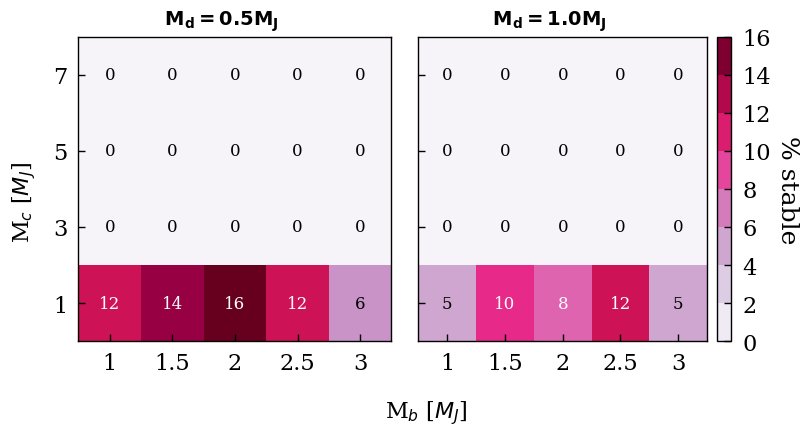

In [ ]:
from plotting_params import use_my_style
use_my_style()

def plot_heatmap_counts(a_lim):
    _, _, _, counts_1 = dict_to_grid(results_even, n_b=5, n_c=4)
    _, _, _, counts_2 = dict_to_grid(results_odd, n_b=5, n_c=4)

    counts_1 = counts_1 
    counts_2 = counts_2 
    fig, ax = plt.subplots(1, 2, figsize=(8,4), sharey=True, sharex=True) 

    #plt.suptitle(rf'Probability of stability ($e_p < 1; R_a < {a_lim}$ au) after 2 Myr [MMR]', fontsize=18, y=1.1) 

    min_val, max_val = 0, max(np.max(counts_1), np.max(counts_2))
    range_val = max_val - min_val

    def annotate_heatmap(ax, count):
        for y_idx in range(4):
            for x_idx in range(5):
                value = count[y_idx, x_idx]
                # if value == 0:
                #     rect = patches.Rectangle((x_idx, y_idx), 1, 1, color='grey')
                #     ax.add_patch(rect)
                #else:
                base_size = 12
                size_factor = 1 + 1.2 * (value - min_val) / range_val
                fontsize = base_size * size_factor
                color = 'white' if value >= 8 else 'black'
                ax.text(x_idx + 0.5, y_idx + 0.5, f'{value:.0f}',
                        ha='center', va='center',
                        color=color, fontsize=base_size)

    all_data = np.concatenate([counts_1, counts_2])
    vmin1, vmax1 = np.nanmin(all_data), np.nanmax(all_data)
    norm = Normalize(vmin=vmin1, vmax=vmax1)

    print(vmax1 - vmin1)

    ticks = np.linspace(0, 16, 9)
    print(ticks)
    bounds = np.linspace(0, 16, 9)

    # Row 1
    fig.text(0.24, 0.95, r" $\mathbf{M_d = 0.5 M_J}$", 
            ha='center', va='center', fontsize=14, fontweight='bold')
    fig.text(0.65, 0.95, r" $\mathbf{M_d = 1.0 M_J}$", 
            ha='center', va='center', fontsize=14, fontweight='bold')

    for i, data in enumerate([counts_1, counts_2]):
        mesh = ax[i].pcolormesh(data, cmap='PuRd', norm = norm, shading='auto')
        annotate_heatmap(ax[i], data)
        if i ==1:
            divider = make_axes_locatable(ax[i])
            cax = divider.append_axes('right', size='5%', pad=0.1)

            cbar = fig.colorbar(mesh, cax=cax, ticks=ticks, boundaries=bounds)
            cbar.set_label('% stable', rotation=270, labelpad=20)
        ax[i].set_xticks(np.arange(5) + 0.5)  # Center ticks
        ax[i].set_yticks(np.arange(4) + 0.5)

        ax[i].set_xticklabels(['1', '1.5', '2', '2.5', '3'])
        ax[i].set_yticklabels(['1', '3', '5', '7'])

        ax[i].minorticks_off()

    fig.text(0.5, -0.04, 'M$_b$ [$M_J$]', fontsize=16, ha='center')
    fig.text(-0.02, 0.5, 'M$_c$ [$M_J$]', fontsize=16, va='center', rotation='vertical')

    plt.tight_layout()#(rect=[0, 0.05, 0.97, 0.97])  # Leave space at bottom/top
    plt.subplots_adjust(hspace=0.3)  # Vertical space between rows
    plt.savefig('plots/three_planet_heatmap_MMR.pdf', bbox_inches='tight')
    plt.show()

plot_heatmap_counts(40)

#### If using 4 M_d values:

### big plot

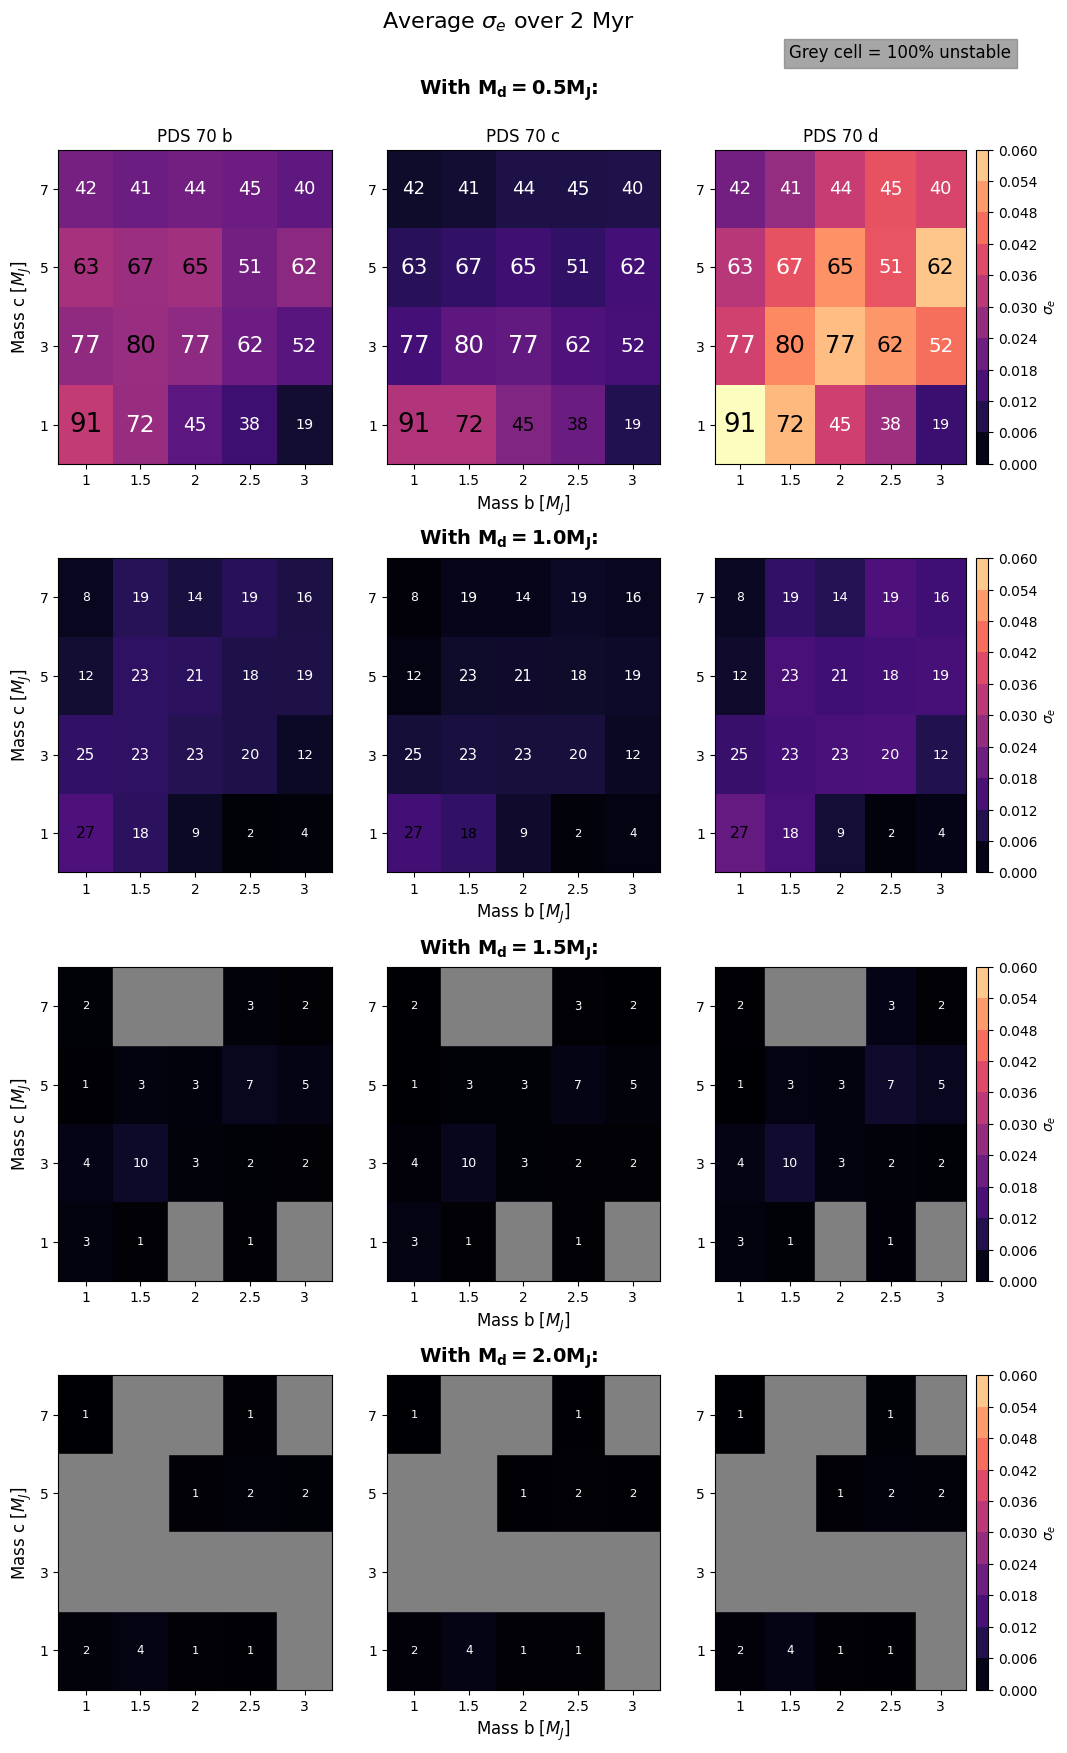

In [5]:
def plot_heatmap_2(ecc=True):

    plot_b_1, plot_c_1, plot_d_1, counts_1 = dict_to_grid(res1, n_b=5, n_c=4, ecc=ecc)
    plot_b_2, plot_c_2, plot_d_2, counts_2 = dict_to_grid(res2, n_b=5, n_c=4, ecc=ecc)
    plot_b_3, plot_c_3, plot_d_3, counts_3 = dict_to_grid(res3, n_b=5, n_c=4, ecc=ecc)
    plot_b_4, plot_c_4, plot_d_4, counts_4 = dict_to_grid(res4, n_b=5, n_c=4, ecc=ecc)

    fig, ax = plt.subplots(4, 3, figsize=(12, 20)) 

    plt.subplots_adjust(hspace=0.1)
    if ecc:
        label = r'$\sigma_e$'
        plt.suptitle(f'Average {label} over 2 Myr', fontsize=16, y=0.95) 
    else: 
        label = r'$\sigma_a$'
        plt.suptitle(f'Average {label} over 2 Myr', fontsize=16, y=0.95)      

    min_val, max_val = 0, 100
    range_val = max_val - min_val

    def annotate_heatmap(ax, count, d):
        for y_idx in range(d.shape[0]):
            for x_idx in range(d.shape[1]):
                value = count[y_idx, x_idx]
                if value == 0:
                    rect = patches.Rectangle((x_idx, y_idx), 1, 1, color='grey')
                    ax.add_patch(rect)
                else:

                    param = d[y_idx, x_idx]

                    base_size = 8
                    size_factor = 1 + 1.5 * (value - min_val) / range_val  # Scales 0.5-2.0
                    fontsize = base_size * size_factor
                    color = 'white' if param <= np.mean(d)+0.005 else 'black'
                    ax.text(x_idx + 0.5, y_idx + 0.5, f'{value:.0f}',
                            ha='center', va='center',
                            color=color, fontsize=fontsize)


    all_data = np.concatenate([plot_b_1, plot_b_2, plot_b_3, plot_b_4,
                               plot_c_1, plot_c_2, plot_c_3, plot_c_4,
                               plot_d_1, plot_d_2, plot_d_3, plot_d_4])
    
    vmin1, vmax1 = np.nanmin(all_data), np.nanmax(all_data)
    norm = Normalize(vmin=vmin1, vmax=vmax1)

    ticks = np.linspace(round(vmin1, 2), round(vmax1, 2), 11)
    bounds = np.linspace(round(vmin1, 2), round(vmax1, 2), 11)

    # Row 1
    fig.text(0.5, 0.91, r"With $\mathbf{M_d = 0.5 M_J}$:", 
            ha='center', va='center', fontsize=14, fontweight='bold')
    
    for i, (data, title) in enumerate(zip([plot_b_1, plot_c_1, plot_d_1], 
                                    ['PDS 70 b', 'PDS 70 c', 'PDS 70 d'])):
        mesh = ax[0,i].pcolormesh(data, cmap='magma', norm=norm, shading='auto')                            
        ax[0,i].set_title(title)
        annotate_heatmap(ax[0,i], counts_1, data)
        #fig.colorbar(mesh, ax=ax[0,2], ticks=ticks, boundaries=bounds)

    fig.text(0.5, 0.685, r"With $\mathbf{M_d = 1.0 M_J}$:", 
            ha='center', va='center', fontsize=14, fontweight='bold')
    # Row 2
    for i, data in enumerate([plot_b_2, plot_c_2, plot_d_2]):
        mesh2 = ax[1, i].pcolormesh(data, cmap='magma', norm = norm, shading='auto')
        annotate_heatmap(ax[1,i], counts_2, data)
        #fig.colorbar(mesh2, ax=ax[1,2], ticks=ticks, boundaries=bounds)

    fig.text(0.5, 0.48, r"With $\mathbf{M_d = 1.5 M_J}$:", 
            ha='center', va='center', fontsize=14, fontweight='bold')

    # Row 3
    for i, data in enumerate([plot_b_3, plot_c_3, plot_d_3]):
        mesh3 = ax[2, i].pcolormesh(data, cmap='magma', norm = norm, shading='auto')
        annotate_heatmap(ax[2,i], counts_3, data)
    #fig.colorbar(mesh3, ax=ax[2,2], ticks=ticks, boundaries=bounds)

    fig.text(0.5, 0.276, r"With $\mathbf{M_d = 2.0 M_J}$:", 
            ha='center', va='center', fontsize=14, fontweight='bold' )

    for i, data in enumerate([plot_b_4, plot_c_4, plot_d_4]):
        mesh4 = ax[3, i].pcolormesh(data, cmap='magma', norm = norm, shading='auto')
        annotate_heatmap(ax[3,i], counts_4, data)
    #fig.colorbar(mesh4, ax=ax[3,2], ticks=ticks, boundaries=bounds)

    plt.annotate(f'Grey cell = 100% unstable', 
                xy=(0.75, 0.85),  # Position in figure coordinates (0-1)
                xycoords='figure fraction',
                ha='center', va='center',
                bbox=dict(facecolor='grey', 
                        alpha=0.7,
                        edgecolor='grey'),
                color='black',
                fontsize=12)# Common labels

    for i in range(4):
        for j in range(3):
            if j == 0:
                ax[i,j].set_ylabel('Mass c [$M_J$]', fontsize=12)
            if j == 1:
                ax[i,j].set_xlabel('Mass b [$M_J$]', fontsize=12)
            if j == 2: 
                divider = make_axes_locatable(ax[i,j])
                cax = divider.append_axes('right', size='5%', pad=0.1)

                fig.colorbar(mesh,cax=cax, ticks=ticks, boundaries=bounds, label=label)

            ax[i,j].set_xticks(np.arange(5) + 0.5)  # Center ticks
            ax[i,j].set_yticks(np.arange(4) + 0.5)
        
            ax[i,j].set_xticklabels(['1', '1.5', '2', '2.5', '3'])
            ax[i,j].set_yticklabels(['1', '3', '5', '7'])

    #plt.tight_layout()#(rect=[0, 0.05, 0.97, 0.97])  # Leave space at bottom/top
    plt.subplots_adjust(hspace=0.3)  # Vertical space between rows
    plt.show()

plot_heatmap_2(ecc=True)

### averages

In [7]:
import cmasher as cmr
from cmasher import combine_cmaps
from plotting_params import use_my_style
use_my_style()
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

colors = [
    "#FFF8E7",  # cream (brightest)
    "#FFE4A3",  # pastel yellow
    "#FFBE62",  # warm orange
    "#FF8A5C",  # orange-pink
    "#E96578",  # muted pink (darker than before)
    "#D04B87",  # richer dark pink
    "#B03E97",  # magenta-purple
    "#7C3FA3",  # mid purple
    "#5548B3",  # indigo-violet
    "#3A4EA6",  # soft blue-indigo
    "#214A89",  # medium blue
    "#0B3E74"   # deep blue (darkest)
]

pastels = LinearSegmentedColormap.from_list(
    "pastels", colors, N=512
)

# reversed version
smooth_map_r = pastels.reversed()
# *Reversed* version (darkest at max value)


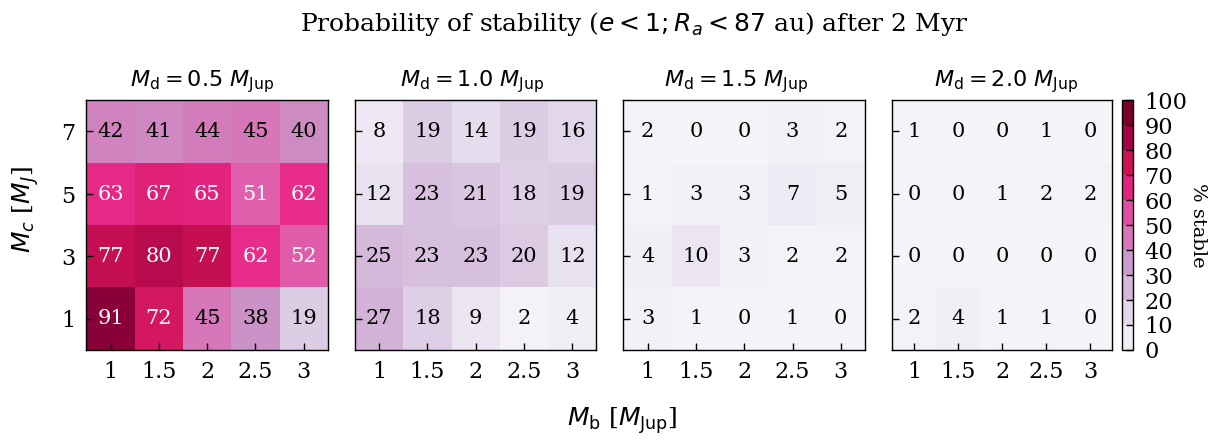

In [10]:


def plot_heatmap_counts_2(a_lim):
    _, _, _, counts_1 = dict_to_grid(res1, n_b=5, n_c=4)
    _, _, _, counts_2 = dict_to_grid(res2, n_b=5, n_c=4)
    _, _, _, counts_3 = dict_to_grid(res3, n_b=5, n_c=4)
    _, _, _, counts_4 = dict_to_grid(res4, n_b=5, n_c=4)

    fig, ax = plt.subplots(1, 4, figsize=(12, 4), sharey=True, sharex=True) 

    plt.suptitle(rf'Probability of stability ($e < 1; R_a < {a_lim}$ au) after 2 Myr', fontsize=18, y=1) 

    min_val, max_val = 0, max(np.max(counts_1), np.max(counts_2), np.max(counts_3), np.max(counts_4))
    range_val = max_val - min_val

    def annotate_heatmap(ax, count):
        for y_idx in range(4):
            for x_idx in range(5):
                value = count[y_idx, x_idx]
                # if value == 0:
                #     rect = patches.Rectangle((x_idx, y_idx), 1, 1, color='grey')
                #     ax.add_patch(rect)
                #else:
                base_size = 10
                size_factor = 1 + 1.3 * (value - min_val) / range_val
                fontsize = base_size * size_factor
                color = 'white' if value >= 50 else 'black'
                ax.text(x_idx + 0.5, y_idx + 0.5, f'{value:.0f}',
                        ha='center', va='center',
                        color=color, fontsize=base_size+5)

    all_data = np.concatenate([counts_1, counts_2, counts_3, counts_4])
    vmin1, vmax1 = np.nanmin(all_data), np.nanmax(all_data)

    norm = Normalize(vmin=0, vmax=100)

    ticks = np.linspace(0, 100, 11)
    bounds = np.linspace(0, 100, 11)

    # Row 1
    fig.text(0.14, 0.82, r"$M_\mathrm{d} = 0.5$ $M_\mathrm{Jup}$", 
            ha='center', va='center', fontsize=16)
    fig.text(0.365, 0.82, r"$M_\mathrm{d} = 1.0$ $M_\mathrm{Jup}$", 
            ha='center', va='center', fontsize=16)
    fig.text(0.585, 0.82, r"$M_\mathrm{d} = 1.5$ $M_\mathrm{Jup}$", 
            ha='center', va='center', fontsize=16)
    fig.text(0.81, 0.82, r"$M_\mathrm{d} = 2.0$ $M_\mathrm{Jup}$", 
            ha='center', va='center', fontsize=16)

    for i, data in enumerate([counts_1, counts_2, counts_3, counts_4]):
        mesh = ax[i].pcolormesh(data, cmap='PuRd', norm = norm, shading='auto')
        annotate_heatmap(ax[i], data)
        if i ==3:
            divider = make_axes_locatable(ax[i])
            cax = divider.append_axes('right', size='5%', pad=0.1)

            cbar = fig.colorbar(mesh, cax=cax, ticks=ticks, boundaries=bounds)

            cbar.ax.set_ylabel('% stable', fontsize=14, labelpad=1, rotation=270, va='bottom')
            
        ax[i].set_xticks(np.arange(5) + 0.5)  # Center ticks
        ax[i].set_yticks(np.arange(4) + 0.5)
        ax[i].minorticks_off()

        ax[i].set_xticklabels(['1', '1.5', '2', '2.5', '3'], fontsize=16)
        ax[i].set_yticklabels(['1', '3', '5', '7'], fontsize=16)

    fig.text(0.49, -0.04, r'$M_\mathrm{b}$ [$M_\mathrm{Jup}$]', fontsize=18, ha='center')
    fig.text(-0.02, 0.5, '$M_c$ [$M_J$]', fontsize=18, va='center', rotation='vertical')
    plt.tight_layout()#(rect=[0, 0.05, 0.97, 0.97])  # Leave space at bottom/top
    
    plt.savefig(f'plots/heatmap_stability_{a_lim}_au.pdf',  bbox_inches='tight')
    plt.savefig(f'plots/heatmap_stability_{a_lim}_au.png',  bbox_inches='tight', dpi=300)

plot_heatmap_counts_2(87)

In [ ]:
import itertools
masses_b = np.linspace(1, 3, 5)
masses_c = np.linspace(1, 7, 4)
masses_d = np.linspace(0.5, 2, 4)

combinations = list(itertools.product(masses_b, masses_c, masses_d))

for i, val in enumerate(combinations):
    print(i, val)


0 (1.0, 1.0, 0.5)
1 (1.0, 1.0, 1.0)
2 (1.0, 1.0, 1.5)
3 (1.0, 1.0, 2.0)
4 (1.0, 3.0, 0.5)
5 (1.0, 3.0, 1.0)
6 (1.0, 3.0, 1.5)
7 (1.0, 3.0, 2.0)
8 (1.0, 5.0, 0.5)
9 (1.0, 5.0, 1.0)
10 (1.0, 5.0, 1.5)
11 (1.0, 5.0, 2.0)
12 (1.0, 7.0, 0.5)
13 (1.0, 7.0, 1.0)
14 (1.0, 7.0, 1.5)
15 (1.0, 7.0, 2.0)
16 (1.5, 1.0, 0.5)
17 (1.5, 1.0, 1.0)
18 (1.5, 1.0, 1.5)
19 (1.5, 1.0, 2.0)
20 (1.5, 3.0, 0.5)
21 (1.5, 3.0, 1.0)
22 (1.5, 3.0, 1.5)
23 (1.5, 3.0, 2.0)
24 (1.5, 5.0, 0.5)
25 (1.5, 5.0, 1.0)
26 (1.5, 5.0, 1.5)
27 (1.5, 5.0, 2.0)
28 (1.5, 7.0, 0.5)
29 (1.5, 7.0, 1.0)
30 (1.5, 7.0, 1.5)
31 (1.5, 7.0, 2.0)
32 (2.0, 1.0, 0.5)
33 (2.0, 1.0, 1.0)
34 (2.0, 1.0, 1.5)
35 (2.0, 1.0, 2.0)
36 (2.0, 3.0, 0.5)
37 (2.0, 3.0, 1.0)
38 (2.0, 3.0, 1.5)
39 (2.0, 3.0, 2.0)
40 (2.0, 5.0, 0.5)
41 (2.0, 5.0, 1.0)
42 (2.0, 5.0, 1.5)
43 (2.0, 5.0, 2.0)
44 (2.0, 7.0, 0.5)
45 (2.0, 7.0, 1.0)
46 (2.0, 7.0, 1.5)
47 (2.0, 7.0, 2.0)
48 (2.5, 1.0, 0.5)
49 (2.5, 1.0, 1.0)
50 (2.5, 1.0, 1.5)
51 (2.5, 1.0, 2.0)
52 (2.5, 3.0, 0.5)
53 

# Plotting 2 planets

In [3]:
files = glob.glob(f'mass_sampling_results/run*2p.nc')

print(files)

['mass_sampling_results/run_60_2000000.0_yr_core_25_2p.nc', 'mass_sampling_results/run_78_2000000.0_yr_core_30_2p.nc', 'mass_sampling_results/run_88_2000000.0_yr_core_3_2p.nc', 'mass_sampling_results/run_26_2000000.0_yr_core_5_2p.nc', 'mass_sampling_results/run_89_2000000.0_yr_core_27_2p.nc', 'mass_sampling_results/run_22_2000000.0_yr_core_0_2p.nc', 'mass_sampling_results/run_72_2000000.0_yr_core_11_2p.nc', 'mass_sampling_results/run_99_2000000.0_yr_core_28_2p.nc', 'mass_sampling_results/run_12_2000000.0_yr_core_33_2p.nc', 'mass_sampling_results/run_13_2000000.0_yr_core_8_2p.nc', 'mass_sampling_results/run_41_2000000.0_yr_core_28_2p.nc', 'mass_sampling_results/run_83_2000000.0_yr_core_15_2p.nc', 'mass_sampling_results/run_93_2000000.0_yr_core_34_2p.nc', 'mass_sampling_results/run_69_2000000.0_yr_core_5_2p.nc', 'mass_sampling_results/run_65_2000000.0_yr_core_17_2p.nc', 'mass_sampling_results/run_51_2000000.0_yr_core_19_2p.nc', 'mass_sampling_results/run_71_2000000.0_yr_core_20_2p.nc', '

In [11]:
from multiprocessing import Pool

def compute_averages(run, max_apo=87):

    run_files = natsorted(glob.glob(f'mass_sampling_results/run_{run}_*2p.nc'))

    active_sims = {i: 0 for i in range(len(run_files))}

    run_count = 0

        #loop through all 100 runs
    for index, mass_combo in enumerate(run_files):
        with netCDF4.Dataset(mass_combo, 'r') as ncfile:
            
            massive_bodies_e = ncfile['planets'][:, 0, :, 2]
            massive_bodies_a = ncfile['planets'][:, 0, :, 3]
            apo_dist = massive_bodies_a * (1 + massive_bodies_e)
            peri_dist = massive_bodies_a * (1- massive_bodies_e)
            #can change stability criteria
            c1 = np.all(massive_bodies_e < 1)
            c2 = np.all(apo_dist <= max_apo)
            c3 = (np.all(apo_dist[:,0] < peri_dist[:,1]) ) 

            if c1 and c2 and c3:
                run_count += 1


                active_sims[index] += 1

    
    return active_sims

all_run_indices = np.arange(100)

with Pool(50) as pool:
    all_active_sims = pool.map(compute_averages, all_run_indices)

In [12]:
from collections import defaultdict

combined_counts = defaultdict(int)

for run_dict in all_active_sims:
    for sim_idx, hits in run_dict.items():
        # hits is a list of 1's (or empty); sum(hits) == number of successes for that sim in this run
        combined_counts[sim_idx] += hits

print(combined_counts)


defaultdict(<class 'int'>, {0: 100, 1: 100, 2: 100, 3: 100, 4: 84, 5: 73, 6: 17, 7: 69, 8: 64, 9: 62, 10: 67, 11: 65, 12: 0, 13: 41, 14: 45, 15: 48, 16: 57, 17: 41, 18: 0, 19: 6, 20: 26, 21: 50, 22: 36, 23: 33, 24: 0, 25: 0, 26: 8, 27: 29, 28: 20, 29: 27, 30: 0, 31: 0, 32: 0, 33: 15, 34: 19, 35: 27})


In [13]:
m_steps = 6
masses = np.linspace(1, 11, m_steps)
mass1_grid, mass2_grid = np.meshgrid(masses, masses)

def make_2pl_grid(results):

    all_kept_sims_grid = np.zeros((6,6))
    
    idx = 0

    for i in range(6):
        for j in range(6):
            all_kept_sims_grid[j, i] = results[idx]
            idx += 1
    
    return all_kept_sims_grid

two_pl_grid = make_2pl_grid(combined_counts)

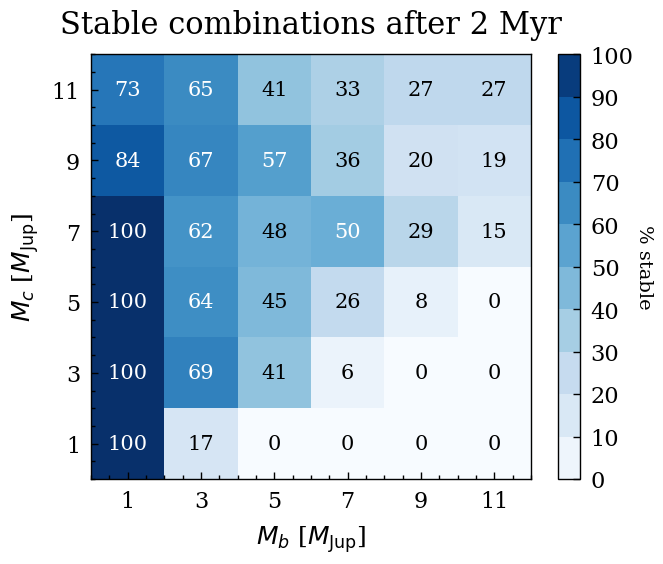

In [14]:
from plotting_params import use_my_style
use_my_style()

def plot_heatmap_counts_2(data, max_apo):

    fig, ax = plt.subplots(figsize=(7,6)) 

    #plt.suptitle(rf'Probability of stability ($e < 1; R_a < {a_lim}$ au) after 2 Myr', fontsize=18, y=1) 

    centres = [1, 3, 5, 7, 9, 11]

    for yidx in range((data.shape[0])):
        for xidx in range((data.shape[1])):

            value = data[yidx,xidx]

            color = 'black' if value < 50 else 'white'
            
            ax.text(centres[xidx], centres[yidx], f'{value:.0f}',
                    ha = 'center', va = 'center', color = color, fontsize=15)


    norm = Normalize(vmin=0, vmax=100)

    ticks = np.linspace(0, 100, 11)
    bounds = np.linspace(0, 100, 11)

    mesh = ax.pcolormesh(mass1_grid, mass2_grid, data, cmap='Blues', norm = norm, shading='auto')
    
    cbar = fig.colorbar(mesh, pad=0.05, ticks=ticks, boundaries=bounds)

    cbar.ax.set_ylabel('% stable', fontsize=14, labelpad=1, rotation=270, va='bottom')
    
    ax.set_xticks(np.arange(1,12,2))  # Center ticks
    ax.set_yticks(np.arange(1,12,2))

    ax.set_xticklabels(['1', '3', '5', '7', '9', '11'], fontsize=16)
    ax.set_yticklabels(['1', '3', '5', '7', '9', '11'], fontsize=16)

    ax.set_xlabel(r'$M_b$ [$M_\mathrm{Jup}$]', fontsize=18)
    ax.set_ylabel(r'$M_c$ [$M_\mathrm{Jup}$]', fontsize=18)
    ax.set_title(rf'Stable combinations after 2 Myr', fontsize=22, y=1.03)
    plt.tight_layout()#(rect=[0, 0.05, 0.97, 0.97])  # Leave space at bottom/top
    
    plt.savefig(f'plots/heatmap_stability_{max_apo}_au_2_pl_UPD_STELLAR_MASS.pdf',  bbox_inches='tight')
    plt.savefig(f'plots/heatmap_stability_{max_apo}_au_2_pl_UPD_STELLAR_MASS.png',  bbox_inches='tight')


plot_heatmap_counts_2(two_pl_grid, 87)